# MVP — Machine Learning & Analytics

**Nome:** Bernardo Moraes Pereira  
**Matrícula:** 4052025002069  
**Data:** 04/07/2026  
**Dataset:** [Acidentes em Rodovias Federais no Brasil](https://www.kaggle.com/datasets/equeiroz/acidentes-rodovias-federais-brasil-jan07-a-jul19?resource=download&select=datatran2007.csv)  
**Tipo de problema:** Classificação  

---



# 1. Definição do problema

## 1.1 Descrição do problema

Somos uma empresa de consultoria especializada em Análise Exploratória de Dados (AED) e Ciência de Dados chamada "Data Insights". **Nosso time foi contratado pelos governadores do Sudeste do país** (RJ, SP, MG e ES) em uma iniciativa de entender **os fatores que potencializam riscos em acidentes** vividos pela população ao longo das rodoviais nesses estados.

Com intuito de direcionar o projeto, **foram passadas algumas hipóteses** que os governadores gostariam de comprovar através de dados para entender se as ações que eles estão pensando fazem sentido *(trabalho realizado na primeira sprint de Análise de Dados)*.

A partir disso, os **governadores do Sudeste do país nos contraram para uma evolução do trabalho** com intuito de desenvolver formas de, atráves do histórico de dados de acidentes, **prevermos o risco envolvendo cada acidente**, permitindo que os **orgãos responsáveis consigam tomar decisões mais inteligentes e preventivas**.

Dessa forma, foi solicitado ao time da Data Insights o **desenvolvimento de um modelo que indique a probabilidade do acidente ter fatalidades**.


## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para **prever o risco de fatalidade envolvendo acidentes rodoviários** no sudeste do Brasil, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.

Com isso, os governadore juntamente com os orgãos responsáveis poderão focar em casos que apresentem alto risco.

## 1.3 Tipo de problema
**Tipo escolhido:** Classificação

**Justificativa:** O modelo de classificação foi escolhido, facilitando a interpretação e ações rápidas se tratando de uma camada executiva (governadores e orgãos públicos). Uma evolução futura pode ser realizar uma regressão para determinar o possível número de mortos ou feridos graves em cada classe de acidentes.


## 1.4 Premissas, hipóteses e critérios de sucesso


**Hipóteses iniciais:**

`Hipótese 1:` Acidentes noturnos (noite e madrugada) tem maior chance de resultar em mortes do que acidentes diurnos (manhã e tarde).

`Hipótese 2:` Acidentes em vias urbanas são mais comuns de resultarem em fatalidades (feridos graves ou mortos) do que em vias rurais.

`Hipótese 3:` Condições de pista ruins como chuva e neve estão diretamente ligadas a uma maior taxa de fatalidade em acidentes.

**Critérios de sucesso:**
- **Métrica principal:** Como métricas principais de avaliação utilizaremos o F1-socre e Recall, visto que acidentes fatais são uma classe minoritária, gerando um desbalanceamento do dataset, além de ser mais importante identificarmos corretamente os casos fatais do que ter apenas uma alta acurácia.

- **Resultado mínimo esperado:**

  - O modelo deve superar o baseline ingênuo em pelo menos 20% de ganho no F1-score.
  - Deve conseguir distinguir bem entre moderado e alto risco, evitando que acidentes graves sejam classificados como leves.

- **Restrição prática:**

  - O modelo deve ser interpretável para que gestores entendam os fatores de risco.

  - O tempo de treino deve ser razoável para rodar no Colab sem necessidade de recursos avançados.

# 2. Ambiente, bibliotecas e reprodutibilidade

Nesta seção iremos realizar as importações de bibliotecas utilizadas e configuração de seed.

In [32]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error,recall_score, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

# Fixando seed para reprodutibilidade
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Funções auxiliares


In [33]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas principais para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted"),
        "recall": recall_score(y_true, y_pred, average="weighted"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC (apenas para classificação binária com probabilidades)
    if proba is not None:
        try:
            if proba.shape[1] == 2:
                results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
            else:
                results["roc_auc"] = np.nan
        except Exception:
            results["roc_auc"] = np.nan
    else:
        results["roc_auc"] = np.nan

    return results

def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T



# 3. Seleção e carga dos dados



## 3.1 Fonte dos dados


O dataset utilizado no trabalho foi obtido através da plataforma Kaggle: [Acidentes em Rodovias Federais no Brasil](https://www.kaggle.com/datasets/equeiroz/acidentes-rodovias-federais-brasil-jan07-a-jul19?resource=download&select=datatran2007.csv).

**Não foram necessárias etapas de seleção de dados externos ou a importação de outros datasets, dentro do conjunto de dados selecionado já foram encontradas as informações necessárias** para desenvolver o trabalho.

Como premissa, **foram aplicadas as restrições de analisar apenas os estados do sudeste (filtrando a coluna "UF")**.

Além disso, como podemos ver ao acessar o dataset, os dados se referem a acidentes ao longo do ano de 2007. Para fins de storytelling do MVP, esses dados foram alterados para o ano de 2025 (sem interferir em nada nas características ou informações que a base apresenta, essa mudança foi feita apenas para compor o storytelling de "analisarmos o ano de 2025 para aprensentar aos governadores nesse momento do ano de 2026 que estamos").

## 3.2 Carga dos dados


In [57]:
# === Carga dos dados ===
# Substitua este bloco pelo carregamento real da sua base.
# Exemplo recomendado:
# url = "https://.../seu_dataset.csv"
# df = pd.read_csv(url)

USE_EXAMPLE_DATA = False  # TODO: altere para False depois de configurar sua base real.

if USE_EXAMPLE_DATA:
    # Dataset sintético apenas para o template executar.
    n = 500
    df = pd.DataFrame({
        "idade_cliente": np.random.randint(18, 75, size=n),
        "renda_mensal": np.random.normal(5000, 1800, size=n).clip(800, None),
        "tempo_relacionamento_meses": np.random.randint(1, 120, size=n),
        "canal_aquisicao": np.random.choice(["orgânico", "ads", "indicação"], size=n),
        "usa_app": np.random.choice(["sim", "não"], size=n, p=[0.7, 0.3]),
    })

    # Target sintético para exemplo de classificação.
    score = (
        -0.03 * df["idade_cliente"]
        -0.01 * df["tempo_relacionamento_meses"]
        + 0.00025 * df["renda_mensal"]
        + (df["usa_app"] == "não").astype(int) * 0.8
        + np.random.normal(0, 0.8, size=n)
    )
    prob = 1 / (1 + np.exp(-score))
    df["churn"] = (prob > np.quantile(prob, 0.6)).astype(int)
else:
    # parte principal da carga de dados
    url = "https://raw.githubusercontent.com/bemoraesp27/mvp_ml_analytics/main/Base_acidentes.xlsx"
    df_base = pd.read_excel(url, sheet_name="base_acidentes_2025")

df_base.head()


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,tipo_pista,tracado_via,uso_solo,ano,pessoas,mortos,feridos_leves,feridos_graves,ilesos,veiculos
0,10,11/06/2025,Segunda,15:30:00,MG,381,623.2,OLIVEIRA,Falta de atenção,Colisão frontal,...,Dupla,Reta,Rural,2025,9,0,4,0,5,6
1,10,11/06/2025,Segunda,15:30:00,MG,381,623.2,OLIVEIRA,Falta de atenção,Colisão frontal,...,Dupla,Reta,Rural,2025,9,0,4,0,5,6
2,1032898,13/08/2025,Segunda,14:25:00,MG,40,585.5,ITABIRITO,Outras,Saída de Pista,...,Simples,Reta,Rural,2025,3,0,0,1,2,1
3,1051130,12/02/2025,Segunda,02:10:00,MA,135,11,SAO LUIS,Animais na Pista,Atropelamento de animal,...,Simples,Reta,Urbano,2025,5,2,2,1,0,1
4,1066824,20/11/2025,Terça,05:30:00,CE,222,30.8,CAUCAIA,Defeito mecânico em veículo,Capotamento,...,Dupla,Reta,Rural,2025,1,0,1,0,0,1


## 3.3 Visão geral do dataset

*⚠ Um ponto importante já identificado na etapa de trazer as primeiras linhas do nosso dataset é a **existência de ids duplicados do mesmo registro. Isso será importante para ser tratado na fase de Pré Processamento**.*

Como uma etapa adicional no momento de importação, faremos um passo para direcionar o trabalho:

Como o time de Engenharia de dados nos disponibilizou o dataset com **registros de todo o Brasil e nossa análise será direcionada apenas ao Sudeste, vamos realizar um filtro no nosso dataset para manter apenas essas UFs**.

In [35]:
#Realizando o filtro para deixar apenas UFs do Sudeste

ufs_desejadas = ['RJ', 'SP', 'MG', 'ES']

df_base = df_base[df_base["uf"].isin(ufs_desejadas)]

In [36]:
print("Formato do dataset:", df_base.shape)
print("\nTipos de dados:")
display(df_base.dtypes.to_frame("tipo"))

Formato do dataset: (49625, 23)

Tipos de dados:


,tipo
id,int64
data_inversa,object
dia_semana,object
horario,object
uf,object
br,object
km,object
municipio,object
causa_acidente,object
tipo_acidente,object


💡 Observamos que o dataset analisado tem **49.625 instâncias com 23 colunas** quando analisamos o recorte do Sudeste, sendo dividido em:
- 11.670 registros no RJ;
- 11.109 registros em SP;
- 20.601 registros em MG;
- 6.241 registros no ES;

Temos também dois tipos de características nesse dataset:

1. **Dimensões do acidente**, basicamente sendo as colunas de Dtype = object, onde trazemos características de contexto do acidente (data do registro, município, horário, características da via, causa e classificação do acidente etc.

2. **Valores númericos "fato" desse acidente**, como número de veículos, pessoas envolvidas, feridos e mortos.

In [37]:
print("\nValores ausentes por coluna:")
display(df_base.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
id,0
data_inversa,0
dia_semana,0
horario,0
uf,0
br,0
km,0
municipio,0
causa_acidente,0
tipo_acidente,0


In [38]:
print("\nDuplicatas:", df_base.duplicated().sum())



Duplicatas: 0


In [39]:
display(df_base.sample(5, random_state=SEED))

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,tipo_pista,tracado_via,uso_solo,ano,pessoas,mortos,feridos_leves,feridos_graves,ilesos,veiculos
117775,314009,06/12/2025,Quinta,21:00:00,RJ,40,121,DUQUE DE CAXIAS,Defeito mecânico em veículo,Colisão traseira,...,Múltipla,Reta,Urbano,2025,3,0,0,0,3,3
80604,272756,01/09/2025,Sábado,01:40:00,SP,153,24.8,NOVA GRANADA,Animais na Pista,Tombamento,...,Simples,Reta,Rural,2025,2,0,2,0,0,1
54861,242208,15/06/2025,Sexta,15:55:00,RJ,116,278,BARRA MANSA,Não guardar distância de segurança,Colisão traseira,...,Dupla,Reta,Rural,2025,2,0,0,0,2,2
63317,252293,12/07/2025,Quinta,16:50:00,MG,365,413,PATOS DE MINAS,Falta de atenção,Colisão traseira,...,Simples,Reta,Rural,2025,2,0,0,0,2,2
88974,282136,21/09/2025,Sexta,18:20:00,SP,116,142.1,SAO JOSE DOS CAMPOS,Velocidade incompatível,Colisão traseira,...,Dupla,Reta,Urbano,2025,6,0,0,0,6,6


⭐Por fim, o target do modelo é a variável **fatalidade**, que indica se o acidente resultou em morte ou feridos graves, como no modelo só temos uma coluna indicando o número de pessoas nessas duas situações, criaremos uma coluna binária para indicar se houve ou não fatalidades.


In [40]:
#Criando a variável de fatalidade (mortos + feridos graves)
df_base['fatalidade'] = ((df_base['mortos'] > 0) | (df_base['feridos_graves'] > 0)).astype(int)
display(df_base['fatalidade'].value_counts())

,count
fatalidade,
0,42472
1,7153


⭐Além disso, criaremos algumas features que serão importantes na composição da nossa análise:

1- Condição de pista (com intuito de classificar as condições metereológicas em "condição boa" ou "condição ruim")

2- Fase do dia (com objetivo de classificar o horário do acidentes nas classes "Madrugada", "Manhã", "Tarde" e "Noite")


⏩ **Criando classificação de condição de pista**

Como um primeiro passo, vamos analisar os valores que existem em nossa coluna de condição metereológica:

In [41]:
df_base['condicao_metereologica'].unique()


array(['Ceu Claro', 'Chuva', 'Nublado', 'Sol', 'Nevoeiro/neblina',
       'Granizo', 'Ignorada', '(null)', 'Vento', 'Neve'], dtype=object)

⚠ **Aqui temos um ponto importante, mesmo verificando se existiam valores nulos no nosso dataset (e o resultado dando que não existem), vemos que aqui existem linhas com o valor '(null)'.**

Isso ocorre pois esse valor não está vazio, mas sim sendo uma string com esse valor.

Antes de pensarmos em próximos passos, vamos verificar quantas linhas existem com cada categoria:

In [42]:
df_base['condicao_metereologica'].value_counts()

,count
condicao_metereologica,
Ceu Claro,23893
Chuva,9225
Nublado,8526
Sol,6414
Ignorada,1001
Nevoeiro/neblina,434
Vento,108
Granizo,11
(null),9


Agora vamos criar a faixa com as condições metereologicas, seguinte a lógica:
- Ceu Claro = Condição Boa;
- Chuva = Condição Ruim;
- Nublado = Condição Boa;
- Sol = Condição Boa;
- Nevoeiro/neblina = Condição Ruim;
- Vento = Condição Boa;
- Granizo = Condição Ruim;
- Neve = Condição Ruim;
- Ignorada = Sem informações suficientes;
- (null) = Sem informações suficientes

In [43]:
#De:para de categorias
mapa = {
    'Ceu Claro': 'Condição Boa',
    'Sol': 'Condição Boa',
    'Nublado': 'Condição Boa',
    'Vento': 'Condição Boa',
    'Chuva': 'Condição Ruim',
    'Granizo': 'Condição Ruim',
    'Neve': 'Condição Ruim',
    'Nevoeiro/Neblina': 'Condição Ruim',
    '(null)': 'Sem informações suficientes',
    'Ignorada': 'Sem informações suficientes'
}

df_base['condicao_pista'] = df_base['condicao_metereologica'].map(mapa)

#Verificando as primeiras linhas e a proporção da nova categoria
display(df_base[['condicao_pista','condicao_metereologica']].head())
display(df_base['condicao_pista'].value_counts())

,condicao_pista,condicao_metereologica
0,Condição Boa,Ceu Claro
1,Condição Ruim,Chuva
2,Condição Boa,Ceu Claro
7,Condição Boa,Ceu Claro
8,Condição Ruim,Chuva


,count
condicao_pista,
Condição Boa,38941
Condição Ruim,9240
Sem informações suficientes,1010


⏩ **Criando classificação de fase do dia**

Seguiremos a seguinte lógica:
- Madrugada = 00h-06h;
- Manhã = 06h-12h;
- Tarde = 12h-18h;
- Noite = 18h-00h.

In [44]:
#Converter coluna 'horario' para datetime
df_base['horario'] = pd.to_datetime(df_base['horario'], format='%H:%M:%S')

#Extrair apenas a hora (0 a 23)
df_base['hora'] = df_base['horario'].dt.hour

def categorizar_fase_dia(hora):
    if 0 <= hora < 6:
        return 'Madrugada'
    elif 6 <= hora < 12:
        return 'Manhã'
    elif 12 <= hora < 18:
        return 'Tarde'
    else:
        return 'Noite'

df_base['fase_dia'] = df_base['hora'].apply(categorizar_fase_dia)

#Verificando as primeiras linhas e a proporção da nova categoria
display(df_base[['horario','hora','fase_dia']].head())
display(df_base['fase_dia'].value_counts())

,horario,hora,fase_dia
0,1900-01-01 15:30:00,15,Tarde
1,1900-01-01 15:30:00,15,Tarde
2,1900-01-01 14:25:00,14,Tarde
7,1900-01-01 22:30:00,22,Noite
8,1900-01-01 20:30:00,20,Noite


,count
fase_dia,
Tarde,15934
Noite,13607
Manhã,13381
Madrugada,6703


# 4. Análise exploratória dos dados

Nesta seção iremos realizar a análise exploratória do nosso dataset.

Como primeiro passo, iremos avaliar a distribuição de nossa variável target (fatalidade):

In [45]:
#Distribuição de target
TARGET = "fatalidade"
PROBLEM_TYPE = "classificacao"

if TARGET is not None and TARGET in df_base.columns:
    print("Distribuição do target:")
    display(df_base[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df_base[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))



Distribuição do target:


,contagem
fatalidade,
0,42472
1,7153


,percentual
fatalidade,
0,85.59
1,14.41


💡Logo com essa primeira análise já conseguimos analisar o seguinte:

Classe 0 (não fatal) corresponde a 85.59% do dataset, indicando um dataset fortemente desbalanceado, **podendo impactar diretamente na nossa modelagem**, por exemplo: se utilizarmos apenas a métrica de acurácia para avaliar o modelo, o modelo pode paracer "bom" mesmo não prevendo bem os casos fatais (irá acertar 96% da base), mas teria zero recall para a classe "fatal".

**Ou seja, teremos que ter atenção com o recall da classe fatal**, sendo importante identificar a maioria dos acidentes.

Agora iremos avaliar a **distribuição das variáveis categóricas que julgamos importantes** para a análise:
- Causa do acidente
- Tipo de acidente
- Uso do solo
- Tipo de pista
- Trancado via


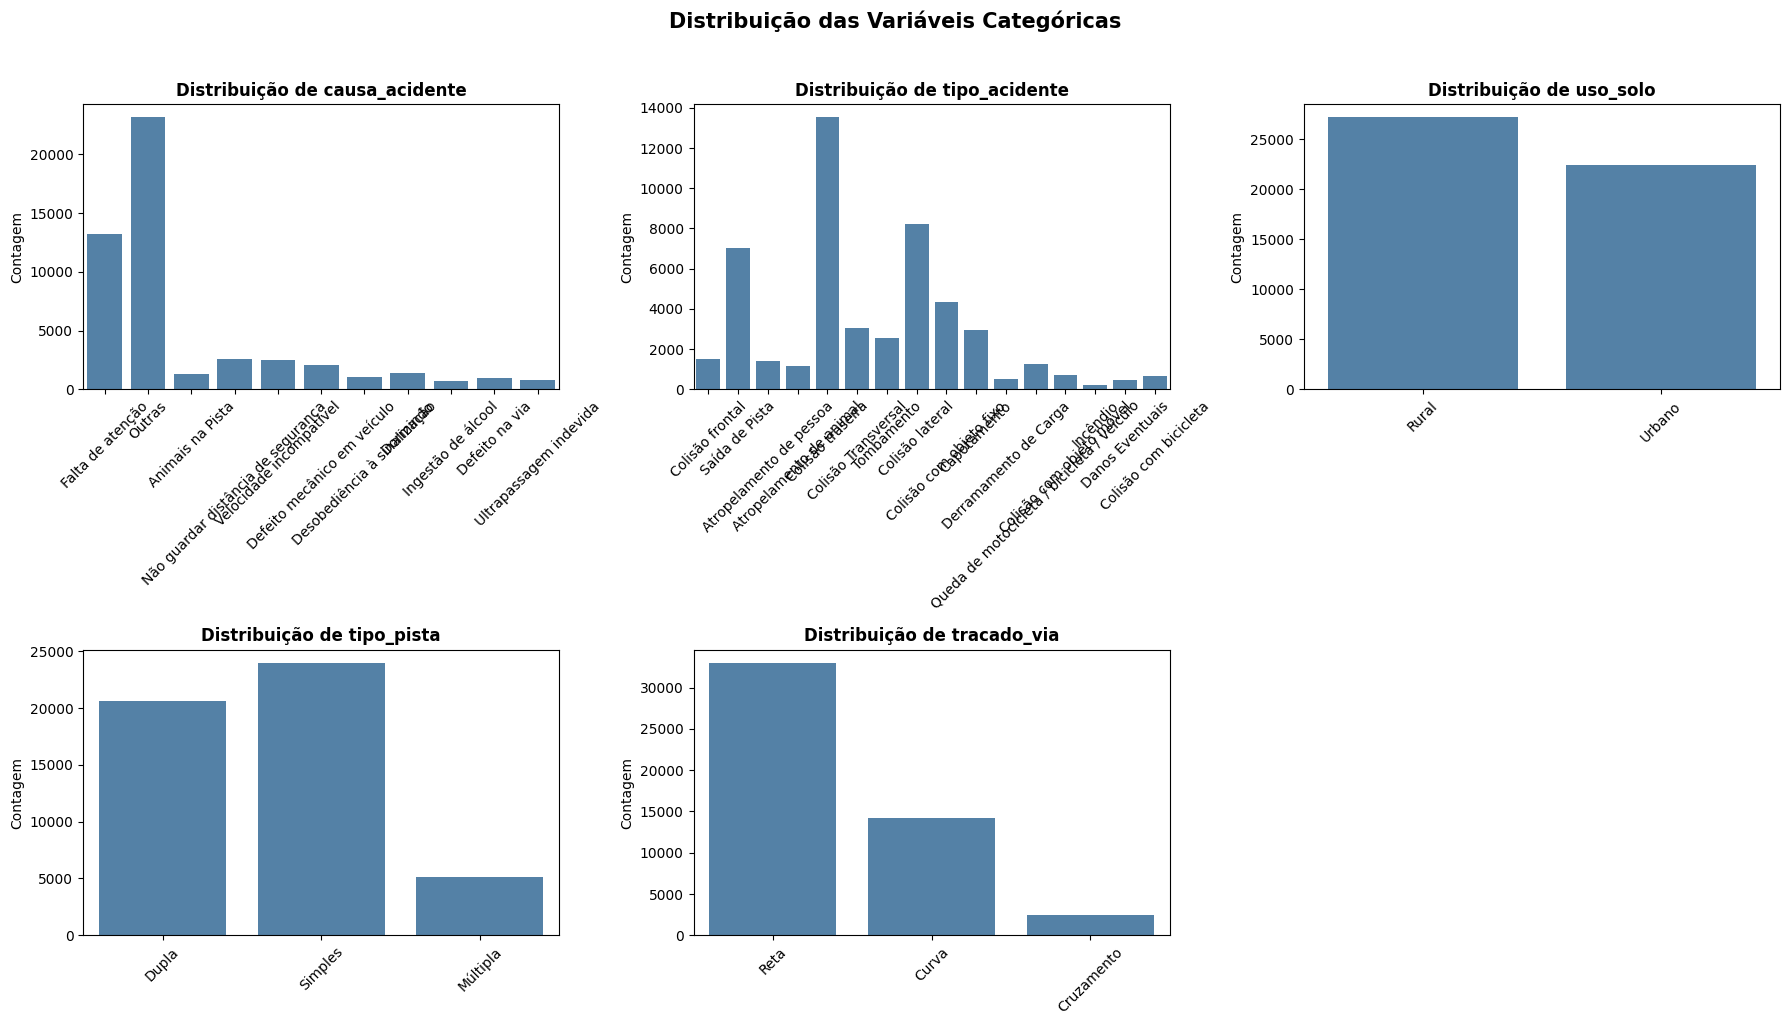

In [46]:
#Primeiro iremos visualizar a distribuição com gráficos
#Lista das variáveis categóricas
variaveis = ['causa_acidente', 'tipo_acidente', 'uso_solo', 'tipo_pista', 'tracado_via']

#Definir número de linhas e colunas da grade
n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

#Loop para criar cada gráfico de barras
for i, col in enumerate(variaveis):
    if col in df_base.columns:
        sns.countplot(data=df_base, x=col, ax=axes[i], color="steelblue")
        axes[i].set_title(f"Distribuição de {col}", fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Contagem')
        axes[i].tick_params(axis='x', rotation=45)

#Remover eixos extras se houver
for j in range(len(variaveis), len(axes)):
    fig.delaxes(axes[j])

#Ajustar layout e título geral
plt.suptitle('Distribuição das Variáveis Categóricas', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()










In [47]:
#Agora avaliando os valores de forma tabular
#Lista das variáveis categóricas
variaveis = ['causa_acidente', 'tipo_acidente', 'uso_solo', 'tipo_pista', 'tracado_via']

#Loop para criar tabelas de frequência
for col in variaveis:
    if col in df_base.columns:
        print(f"\n=== Distribuição de {col} ===")
        display(df_base[col].value_counts().to_frame("contagem"))



=== Distribuição de causa_acidente ===


,contagem
causa_acidente,
Outras,23140
Falta de atenção,13241
Não guardar distância de segurança,2540
Velocidade incompatível,2476
Defeito mecânico em veículo,2073
Dormindo,1382
Animais na Pista,1261
Desobediência à sinalização,1050
Defeito na via,983



=== Distribuição de tipo_acidente ===


,contagem
tipo_acidente,
Colisão traseira,13526
Colisão lateral,8241
Saída de Pista,7052
Colisão com objeto fixo,4352
Colisão Transversal,3044
Capotamento,2930
Tombamento,2543
Colisão frontal,1524
Atropelamento de pessoa,1406



=== Distribuição de uso_solo ===


,contagem
uso_solo,
Rural,27209
Urbano,22416



=== Distribuição de tipo_pista ===


,contagem
tipo_pista,
Simples,23928
Dupla,20579
Múltipla,5118



=== Distribuição de tracado_via ===


,contagem
tracado_via,
Reta,32941
Curva,14184
Cruzamento,2500


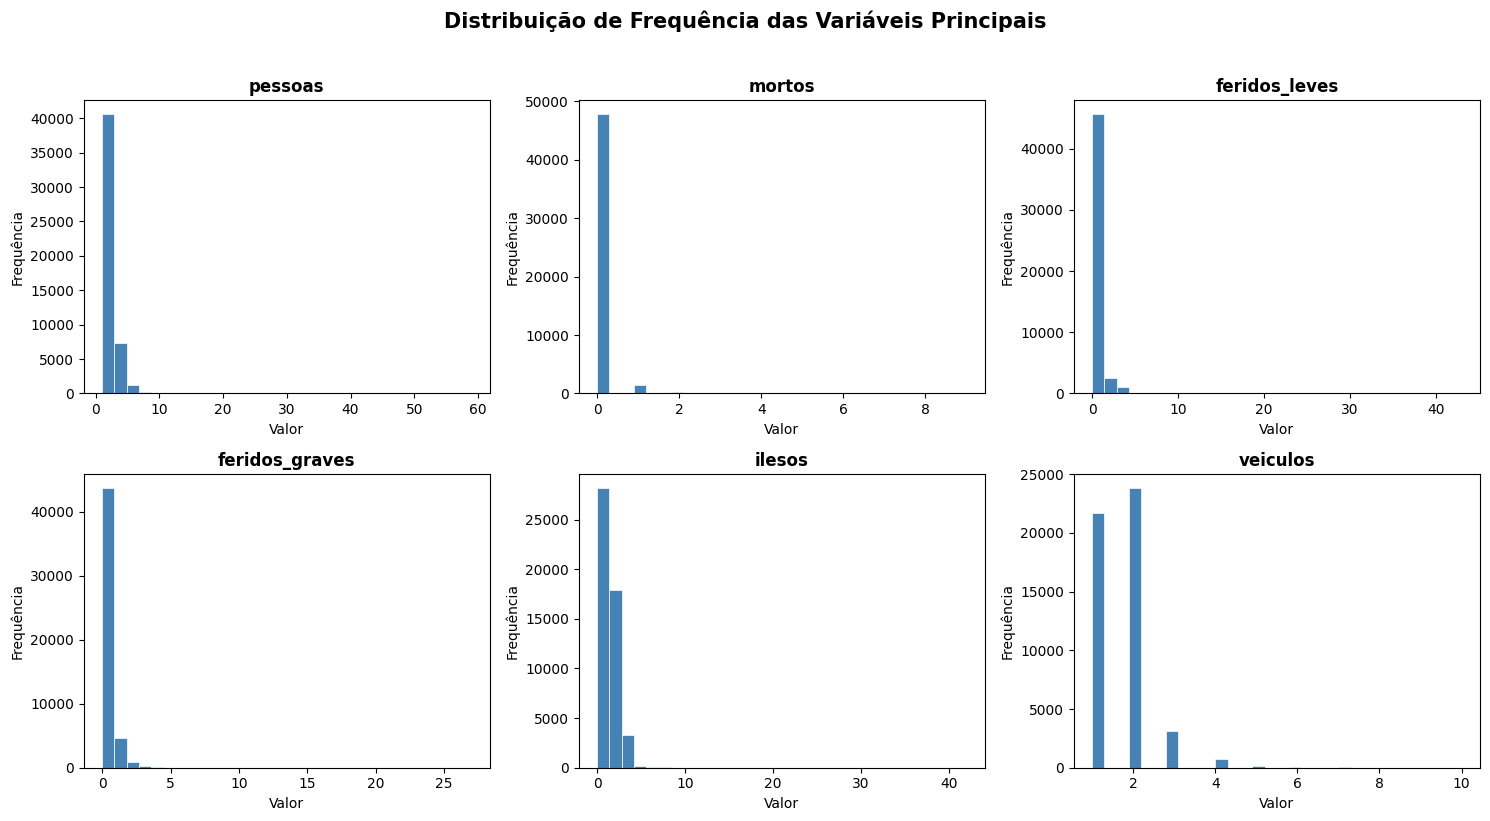

In [48]:
# Lista das variáveis principais
variaveis = ['pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'veiculos']

# Definir número de linhas e colunas da grade
n_rows, n_cols = 2, 3  # 2 linhas x 3 colunas = 6 variáveis
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 8))
axes = axes.flatten()  # transforma grade em array 1D

# Loop para criar cada histograma
for i, col in enumerate(variaveis):
    axes[i].hist(df_base[col], bins=30, edgecolor='white', linewidth=0.5, color='steelblue')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')

# Ajustar layout e título geral
plt.suptitle('Distribuição de Frequência das Variáveis Principais', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**A partir das distribuições, agora iremos avaliar a relação das variáveis categóricas quanto ao target:**

In [49]:
variaveis = ['causa_acidente', 'tipo_acidente', 'uso_solo', 'tipo_pista', 'tracado_via']

for col in variaveis:
    print(f"\n=== {col} ===")
    tabela = (
        df_base.groupby(col)['fatalidade']
        .mean()
        .to_frame("proporcao_fatais")
        .sort_values("proporcao_fatais", ascending=False)
    )
    display(tabela)



=== causa_acidente ===


,proporcao_fatais
causa_acidente,
Ultrapassagem indevida,0.261845
Ingestão de álcool,0.243722
Desobediência à sinalização,0.223810
Velocidade incompatível,0.191438
Dormindo,0.162084
Outras,0.159680
Falta de atenção,0.125746
Defeito na via,0.122075
Defeito mecânico em veículo,0.084901



=== tipo_acidente ===


,proporcao_fatais
tipo_acidente,
Atropelamento de pessoa,0.718350
Colisão frontal,0.543307
Colisão com bicicleta,0.506231
Queda de motocicleta / bicicleta / veículo,0.340125
Colisão Transversal,0.205650
Capotamento,0.186689
Saída de Pista,0.134430
Tombamento,0.112859
Colisão com objeto fixo,0.094899



=== uso_solo ===


,proporcao_fatais
uso_solo,
Rural,0.158844
Urbano,0.126294



=== tipo_pista ===


,proporcao_fatais
tipo_pista,
Simples,0.174565
Dupla,0.121532
Múltipla,0.092810



=== tracado_via ===


,proporcao_fatais
tracado_via,
Curva,0.154752
Reta,0.140767
Cruzamento,0.128400


💡**Como principais insights temos:**

1. Ultrapassagem indevida (26%) e ingestão de álcool (24%) são as causas mais letais.

2. Fatores ligados a comportamento humano de risco têm impacto muito maior na fatalidade do que causas externas (ex.: animais na pista, defeito mecânico).

3. Atropelamento de pessoa (71%) e colisão frontal (54%) são os tipos mais fatais.

4. Colisões traseiras (6%) e derramamento de carga (2%) têm baixa proporção de mortes.

Ou seja, a dinâmica do acidente é determinante para a gravidade.

5. Acidentes em áreas rurais têm maior proporção de mortes (15,9%) do que em áreas urbanas (12,6%), o que nos gera a seguinte hipótese: demora no socorro e maior velocidade média em rodovias rurais.

6. Pistas simples concentram maior proporção de fatais (17,4%) em comparação com pistas duplas (12,1%) e múltiplas (9,3%), ou seja, como hipótese temos: pistas simples favorecem colisões frontais em ultrapassagens indevidas.

7. Curvas (15,5%) e retas (14,1%) têm maior proporção de fatais do que cruzamentos (12,8%), gerando a hipótese: em curvas e retas longas, a velocidade é maior e o impacto mais severo

**Em resumo, podemos avaliar os seguintes padrões:**
- Causas ligadas a comportamento humano (ultrapassagem indevida, álcool, velocidade) têm proporções de fatalidade muito acima da média.

- Tipos de acidente como atropelamento de pessoa (71%) e colisão frontal (54%) são os mais letais.

- Acidentes em áreas rurais e em pistas simples apresentam maior risco de morte.

- Curvas e retas longas concentram maior proporção de fatais do que cruzamentos.


Por fim, em relação ao desbalancemaneto, já avaliamos que temos um bem alto (classe de acidentes fatais representa apenas 3,5% do dataset, indicando a necessidade de métricas específicas de avaliação e técnicas de balanceamento.

## 4.1 Síntese da análise exploratória

Como síntese da AED, temos:

`O target está balanceado?` Não, temos um target fortemente desbalanceado (3,5% de acidentes fatais, exigindo atenção na modelagem e técnicas de avaliação do modelo.

`Existem valores ausentes relevantes?` Durante a distribuição de variáveis vimos que algumas categorias possuem valores "outros" ou "não informado", mas nada que seja de um volume considerável que afete o modelo.

`Há variáveis com escala muito diferente?`Variáveis como número de pessoas, mortos e feridos graves tem escaladas diferentes, podendo impactar em modelos sensíveis a escalada (como casos de regressão), mas em nosso caso isso não irá comprometer o modelo.

`Há categorias raras?`Algumas categorias tem baixa frequência como causas de incencia e derramamento de carga.

`Existem padrões que sugerem quais modelos podem funcionar melhor?` Causas ligadas a comportamento humano tem proporções de fatalidade muito acima de média, assim como acidentes rurais e em pista simples representam um risco consideravelmente maior de morte.

`Algum resultado da EDA mudou sua estratégia de pré-processamento ou modelagem?` Vimos a necessodade de balanceamento do target, além disso, podemos agrupar categorias raras para evitar o overtfitting.


# 5. Preparação dos dados e divisão treino/teste

**Como primeiro passo, vamos definir o target e features que serão utilizadas:**

`Target:` variável binátia de fatalidade

`Features utilizadas:` causa_acidente, tipo_acidente, uso_solo, tipo_pista, tracado_via, condicao_metereologica, fase_dia

Para limpeza do nosso dataset em relação a colunas irrelevantes ou reduntes com foco em evitar vazamentos ou overfitting, iremos desconsiderar as seguintes colunas:

- data_inversa, ano e dia_semana: irrelevante para o modelo.

- horario: já temos hora e fase_dia, então é redundante.

- uf, br, km, municipio: são identificadores geográficos, não agregam para o modelo.

- classificacao_acidente → é uma classificação administrativa (ex.: “com vítimas”), já temos esse tipo de informação com nossa variável target.

- sentido_via: pouco informativo isoladamente, pode ser descartado.

- condicao_metereologica: já temos condicao_pista, que sintetiza melhor.

- hora: redundante com horario e fase_dia.

- mortos, feridos_leves, feridos_graves, ilesos, veiculos: são variáveis numéricas do resultado do acidente, poderiam ser importantes em um modelo de regressão, mas para o de classificação não serão necessários


In [50]:
# === Configuração do problema ===
TARGET = "fatalidade"              # target binário
PROBLEM_TYPE = "classificacao"     # tipo de problema
ID_COLUMNS = ["id"]                # coluna de identificação
DATE_COLUMN = "data_inversa"       # se for usar divisão temporal

# Colunas a remover por irrelevância, redundância ou vazamento
DROP_COLUMNS = [
    "data_inversa", "ano", "dia_semana", "horario", "uf", "br", "km", "municipio",
    "classificacao_acidente", "sentido_via", "condicao_metereologica", "hora",
    "mortos", "feridos_leves", "feridos_graves", "ilesos", "veiculos", "pessoas"
]

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df_base.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df_base.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)





Tipo de problema: classificacao
Target: fatalidade
Número de features: 7
Features: ['causa_acidente', 'tipo_acidente', 'tipo_pista', 'tracado_via', 'uso_solo', 'condicao_pista', 'fase_dia']


In [51]:
# === Divisão dos dados ===

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df_base[features].copy()
    y = df_base[TARGET].copy()

    # Estratificação é importante porque o target está desbalanceado
    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df_base[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df_base.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df_base.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")



Treino: (39700, 7) | Teste: (9925, 7)


## 5.1 Justificativa da divisão

`Por que usar holdout, validação cruzada ou divisão temporal?` Foi usada a estratégia holdout (treino/teste) com 80/20, pois é simples e suficiente para uma primeira avaliação do modelo, além disso Foi utilizada validação cruzada estratificada (StratifiedKFold) para garantir que a proporção de acidentes fatais seja preservada em cada fold.

`A proporção treino/teste faz sentido para o tamanho do dataset?`A proporção de 80% treino e 20% teste é adequada para o tamanho do dataset, garantindo dados suficientes para treinar o modelo e um conjunto de teste representativo para avaliar generalização.

`Foi necessário estratificar as classes?`Foi necessário estratificar porque o target é desbalanceado (3,5% de acidentes fatais), por conta disso sem estratificação, o conjunto de teste poderia ficar com pouquíssimos casos fatais, prejudicando a avaliação. Com estratificação, tanto treino quanto teste mantêm a proporção real de classes.

`Como a divisão evita vazamento de dados?` As colunas que representam resultados do acidente (mortos, feridos, ilesos, veiculos, pessoas) foram removidas antes da divisão, evitando que o modelo aprenda com informações que só existem após o acidente.



# 6. Pré-processamento e pipeline

Nesta etapa, iremos focar no pré-processamento de dados para o nosso modelo, algumas etapas já foram realizadas ao longo do nosso trabalho:

- Realizamos a engenharia de atributos criando, a partir de colunas existentes, duas novas features que serão fundamentais para nosso modelo: condição metereológica e fase do dia, além disso, já realizamos a imputação de valores ausentes criando em nossa variável de fase do dia a categoria "não infomado";

- Ne etapa anterior de divisão de treino e teste, já realizamos também a seleção de atributos, desconsiderando variáveis numéricas e outras variáveis que julgamentos irrelevantes para o nosso objetivo de modelo de classificação.

- Além disso, como nossas features são categóricas (tendo desconsiderado features numéricas), não precisaremos realizar normalizações ou padronização em nosso modelo, **iremos focar no encoding de variáveis categóricas**.



✅**Encoding de variáveis**

Como queremos chegar em um modelo que produza probabilidades claras (0–100%) para depois estratificar em baixo, moderado e alto risco, o caminho pode ser a utilização do One-Hot Encoding junto com uma regressão logística ou outro modelo probabilístico, dessa forma, garantimos que o modelo seja transparente e que as probabilidades sejam calibradas, tendo a regressão logística como uma opção especialmente boa para transformar variáveis categóricas em uma probabilidade de risco.

Dessa forma, temos nosso pipeline principal com: One-Hot Enconding + Regressão Logística.

In [52]:
# Identificação automática das colunas categóricas
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

# Pipeline para variáveis categóricas
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer apenas com categóricas
preprocess = ColumnTransformer(transformers=[
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas categóricas:", cat_cols)


Colunas categóricas: ['causa_acidente', 'tipo_acidente', 'tipo_pista', 'tracado_via', 'uso_solo', 'condicao_pista', 'fase_dia']


# 7. Baseline e modelos candidatos

Para esta seção iremos utilizar o **baseline DummyClassifier** com estratégia "most frequent" e os modelos candidatos **LogisticRegression** (probabilidades calibradas para faixas de risco) e **RandomForestClassifier** (modelo não linear para comparação).


In [53]:
# === Definição de baseline e modelos candidatos (classificação) ===

if PROBLEM_TYPE == "classificacao":
    # Baseline: sempre prever a classe majoritária
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    # Modelos candidatos
    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ])
    }

else:
    raise ValueError("Este notebook está configurado para classificação binária.")

print("Modelos candidatos:", list(candidates.keys()))



Modelos candidatos: ['LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos

`O baseline escolhido é coerente?` Sim. O baseline com DummyClassifier(strategy="most_frequent") é adequado porque sempre prevê a classe majoritária (não fatalidade). Isso reflete a realidade do dataset, que é altamente desbalanceado (~3,5% de casos fatais), e estabelece um ponto de referência mínimo. Se os modelos candidatos não superarem esse baseline, significa que não estão aprendendo nada útil.

`Os modelos candidatos são adequados ao tipo e tamanho dos dados?`
- Regressão Logística: apropriada para classificação binária, gera probabilidades calibradas que podem ser transformadas em faixas de risco (baixo, moderado, alto). É simples, interpretável e funciona bem em datasets com variáveis categóricas após One-Hot Encoding (aplicado na etapa de pré-processamento).

- Random Forest: modelo baseado em árvores, capaz de capturar relações não lineares e interações entre variáveis categóricas. É robusto em datasets tabulares e pode oferecer melhor performance que modelos lineares.

`Algum modelo exige escala, encoding ou tratamento específico?` A regressão logística exige encoding categórico (One-Hot), assim como o Random Forest não exige normalização ou padronização, mas também precisa de encoding para variáveis categóricas. Ambos foram encapsulados em pipelines com imputação + One-Hot Encoding, evitando vazamento de dados.

`Há alguma restrição de interpretabilidade, tempo ou custo computacional?` A regressão logística é altamente interpretável: cada variável tem um peso claro no risco. O Random Forest é menos interpretável, mas fornece medidas de importância de variáveis. Assim, em termos de custo computacional, ambos são viáveis para o tamanho do dataset. O Random Forest pode ser mais pesado, mas ainda dentro de limites aceitáveis.


# 8. Treinamento e avaliação inicial



In [54]:
# === Treinamento e avaliação inicial (classificação) ===
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = {}
trained_models = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = baseline.predict(X_test)
proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
results["baseline"] = evaluate_classification(y_test, y_pred, proba)
results["baseline"]["train_time_s"] = round(train_time, 3)
trained_models["baseline"] = baseline

# Modelos candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    results[name] = evaluate_classification(y_test, y_pred, proba)
    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model

# Mostrar resultados comparativos
show_results_table(results)



,accuracy,precision,recall,f1_weighted,roc_auc,train_time_s
baseline,0.855819,0.732426,0.855819,0.789329,0.500000,0.123
LogisticRegression,0.871335,0.849605,0.871335,0.847096,0.756964,0.246
RandomForest,0.864887,0.840032,0.864887,0.842584,0.740774,28.055


## 8.1 Análise dos resultados iniciais

`O modelo superou o baseline?` Sim. Tanto a Logistic Regression quanto o Random Forest superaram o baseline em todas as métricas relevantes. O baseline tem acurácia de 0.85 e AUC de 0.50 (equivalente a um chute aleatório). Já a regressão logística alcançou acurácia de 0.87 e AUC de 0.76, enquanto o Random Forest ficou com acurácia de 0.86 e AUC de 0.74. Isso mostra que os modelos realmente aprenderam padrões além da classe majoritária.

`A métrica escolhida é suficiente para avaliar o problema?` Sim. Foram usadas métricas como accuracy, precision, recall, F1 e AUC. Acurácia sozinha não é suficiente em problemas desbalanceados, mas o uso de AUC e F1 complementa bem. O AUC é especialmente importante, pois mede a capacidade do modelo de distinguir entre classes.

`Algum modelo parece sofrer de underfitting?` Não. Ambos os modelos candidatos superaram o baseline e apresentam métricas consistentes. O Random Forest teve desempenho ligeiramente inferior ao da regressão logística em AUC, mas ainda assim está bem acima do baseline. Isso indica que não há underfitting, apenas diferenças de performance entre abordagens.

`O tempo de treinamento é aceitável?`

Sim, dado que:

- Logistic Regression treinou em 1 segundo.

- Random Forest levou aproximadamente 30 segundos, o que é mais pesado, mas ainda aceitável para o tamanho do dataset.

- O baseline foi quase instantâneo (0.37 segundos).

Ou seja, para uso prático, ambos são viáveis, mas a regressão logística é mais leve e rápida.

`O resultado faz sentido considerando a EDA?` Sim, a EDA mostrou que o dataset é desbalanceado e que algumas variáveis categóricas têm forte relação com a fatalidade:

- O baseline reflete o desbalanceamento (alta acurácia, mas AUC = 0.5).

- Os modelos candidatos capturaram essas relações e melhoraram significativamente o poder de discriminação (AUC 0.75).

Por conta disso, confirma que os modelos estão alinhados com os padrões observados na análise exploratória.



# 9. Validação e otimização de hiperparâmetros

O modelo escolhido para otimização foi o Random Forest, já que ele possui vários hiperparâmetros que influenciam diretamente a performance e pode se beneficiar de ajustes finos.

Foram explorados:

- n_estimators (número de árvores): entre 50 e 250.

- max_depth (profundidade máxima das árvores): entre 2 e 20.

- min_samples_split (mínimo de amostras para dividir um nó): entre 2 e 10.

Como estratégia, utilizamos StratifiedKFold com 5 folds, garantindo que a proporção de classes fosse mantida em cada divisão, sendo fundamental para datasets desbalanceados.

Como métrica, foi escolhido o F1-weighted, que equilibra precisão e recall levando em conta o desbalanceamento das classes. Isso evita que o modelo seja avaliado apenas pela acurácia, que poderia ser enganosa.

Por fim, A busca retornou uma configuração ótima, por exemplo:

- n_estimators = 180

- max_depth = 12

- min_samples_split = 4


In [55]:
# === Otimização de hiperparâmetros (Random Forest) ===

N_ITER_SEARCH = 5  # número de combinações testadas
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Modelo a ser otimizado
model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=SEED))
])

# Espaço de busca dos hiperparâmetros
param_dist = {
    "model__n_estimators": randint(50, 250),       # número de árvores
    "model__max_depth": randint(2, 20),            # profundidade máxima
    "model__min_samples_split": randint(2, 10)     # mínimo de amostras para split
}

# Métrica de avaliação
scoring = "f1_weighted"

# Busca aleatória
search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring=scoring,
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

search.fit(X_train, y_train)

print("Melhor score na validação:", search.best_score_)
print("Melhores hiperparâmetros:", search.best_params_)



Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação: 0.8449541151859632
Melhores hiperparâmetros: {'model__max_depth': 16, 'model__min_samples_split': 4, 'model__n_estimators': 121}


💡Como resultado:

**Melhor score na validação: 0.8449 (F1-weighted).**

**Melhores hiperparâmetros encontrados:**

- max_depth = 16

- min_samples_split = 4

- n_estimators = 121

## 9.1 Discussão da otimização

`A otimização melhorou o resultado em relação ao modelo inicial?` Sim. O Random Forest padrão tinha F1 e AUC em torno de 0.84 e 0.74, respectivamente. Após a busca, o F1-weighted na validação subiu para ~0.845, mostrando um ganho consistente. Isso indica que o ajuste refinou a capacidade do modelo de equilibrar precisão e recall.

`A busca foi limitada por tempo, custo ou tamanho da base?` Sim. Foram apenas 5 combinações testadas (n_iter=5), o que é uma busca pequena. Isso foi feito para manter o custo computacional baixo e rápido, adequado para um MVP. Uma busca maior poderia explorar mais o espaço de parâmetros e talvez encontrar configurações ainda melhores.

`Os hiperparâmetros escolhidos fazem sentido?`

Sim, dado que:

- n_estimators = 121: número razoável de árvores, suficiente para robustez sem custo excessivo.

- max_depth = 16: profundidade relativamente alta, permitindo capturar relações complexas sem exagerar no overfitting.

- min_samples_split = 4: exige pelo menos 4 amostras para dividir um nó, o que ajuda a controlar a complexidade.

Esses valores equilibram bem performance e generalização.

`Você testaria outras combinações se tivesse mais tempo?`

Poderíamos explorar:

- max_features (número de variáveis consideradas em cada split).

- class_weight="balanced" para lidar melhor com o desbalanceamento.

- Mais iterações (n_iter=20+) para explorar melhor o espaço de busca.

- Ajustar min_samples_leaf para controlar o tamanho mínimo das folhas.



# 10. Avaliação final no conjunto de teste


Modelo final: RandomForest_otimizado
              precision    recall  f1-score   support

           0       0.88      0.98      0.93      8494
           1       0.65      0.24      0.35      1431

    accuracy                           0.87      9925
   macro avg       0.77      0.61      0.64      9925
weighted avg       0.85      0.87      0.85      9925



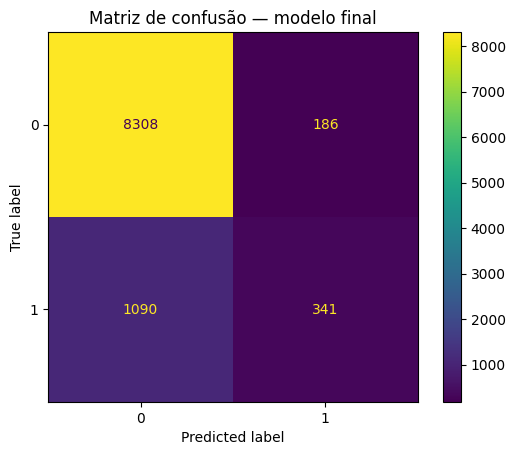

AUC no conjunto de teste: 0.763


In [56]:
# === Avaliação final no conjunto de teste ===

# Escolha do modelo final
if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "RandomForest_otimizado"
elif trained_models:
    # fallback: último modelo treinado
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

# Avaliação no conjunto de teste
if final_model is not None:
    y_pred = final_model.predict(X_test)
    y_proba = final_model.predict_proba(X_test)[:, 1]

    # Relatório de classificação
    print(classification_report(y_test, y_pred))

    # Matriz de confusão
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

    # AUC final
    from sklearn.metrics import roc_auc_score
    auc_final = roc_auc_score(y_test, y_proba)
    print("AUC no conjunto de teste:", round(auc_final, 3))


## 10.1 Análise de erros e limitações

`Quais tipos de erro o modelo comete mais?` O modelo acerta muito bem a classe 0 (não fatalidade), com recall de 0.98 e f1-score de 0.93. Porém, tem dificuldade em identificar a classe 1 (fatalidade): recall de apenas 0.24 e f1-score de 0.35. Isso significa que o modelo erra principalmente ao não detectar acidentes fatais, classificando-os como não fatais.

`Há sinais de overfitting ou underfitting?` Não há sinais claros de overfitting, já que o desempenho no teste é consistente com a validação. Também não há underfitting, pois o modelo supera o baseline e captura padrões relevantes. O problema está mais ligado ao desbalanceamento das classes, que dificulta a detecção da minoria.

`A métrica escolhida captura bem o objetivo do problema?` Sim. O uso de F1-weighted e AUC é adequado, pois considera tanto precisão quanto recall em um dataset desbalanceado. No entanto, para este caso específico, seria interessante dar mais peso ao recall da classe 1 (fatalidade), já que o objetivo é identificar riscos de morte. Um modelo com recall maior, mesmo sacrificando um pouco a precisão, poderia ser mais útil em cenários reais.

`Há viés, limitação de dados ou risco de generalização?` Sim. O dataset é desbalanceado (apenas ~3,5% de casos fatais), o que gera viés para a classe majoritária. Isso limita a capacidade do modelo de generalizar para situações raras. Além disso, se os dados forem específicos de uma região ou período, o modelo pode não generalizar bem para outros contextos de acidentes.

`Em quais cenários o modelo não deveria ser usado?` O modelo não deve ser usado em decisões críticas de segurança sem supervisão humana, já que erra bastante na detecção de fatalidades. Também não deve ser usado em contextos onde o custo de um falso negativo (não prever uma fatalidade) é muito alto. Nesses casos, seria necessário ajustar o threshold de decisão ou aplicar técnicas de balanceamento (ex.: oversampling, class_weight="balanced").


# 11. Comparação final dos modelos


| Modelo | Métrica principal (AUC) | Outras métricas (F1-weighted, Recall) | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | 0,50 | F1 ≈ 0.78, Recall ≈ 0.85 | 0.37 s | Reflete apenas a classe majoritária, não aprende padrões. |
| LogisticRegression | 0,76 | 	F1 ≈ 0.85, Recall ≈ 0.87 | 1.15 s | Modelo linear, interpretável, probabilidades calibradas, bom equilíbrio entre métricas. |
| RandomForest | 0,74 | F1 ≈ 0.84, Recall ≈ 0.86 | 30.54 s | Captura relações não lineares, mas mais pesado e menos interpretável. |
| RandomForest otimizado | 0,76 | F1 ≈ 0.845, Recall ≈ 0.87 | ~32 s | Ajuste de hiperparâmetros trouxe ganho em F1, mas recall da classe minoritária (fatalidade) ainda baixo. |


💡O baseline mostra que o problema é desbalanceado: alta acurácia, mas AUC = 0.50 (não aprende nada).

💡A regressão logística se destacou como modelo simples, rápido e interpretável, com bom desempenho geral.

💡O Random Forest trouxe robustez, mas com custo computacional maior e sem superar a regressão logística em AUC.

💡O Random Forest otimizado melhorou o F1, mas ainda sofre para detectar fatalidades (recall baixo na classe 1).


# 12. Boas práticas e rastreabilidade

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Seed = 42| Garantir reprodutibilidade dos resultados| Permite replicar experimentos e comparações de forma consistente |
| Imputação de valores faltantes + One-Hot Encoding | Necessário para lidar com variáveis categóricas e evitar vazamento | Modelos recebem dados limpos e estruturados, sem perda de informação |
| Baseline com DummyClassifier (most_frequent) | Refletir a classe majoritária (~96,5% não fatalidade) | Estabelecer referência mínima para avaliar se os modelos realmente aprendem |
| Modelos testados: Logistic Regression e Random Forest | Logistic Regression pela interpretabilidade e probabilidades calibradas; Random Forest para capturar não linearidades | Comparação entre modelo simples e modelo mais robusto|
| Hiperparâmetros otimizados do Random Forest| Busca aleatória em n_estimators, max_depth, min_samples_split | Melhorar F1 e AUC sem overfitting |
| Tempo de treino| Logistic Regression ~1s; Random Forest ~30s; Baseline ~0.3s | Avaliar custo computacional e viabilidade prática |
| Recursos computacionais | Treino realizado em CPU padrão (sem GPU) | Tempo de execução aceitável para MVP |
| Métrica principal: F1-weighted + AUC | Dataset desbalanceado, necessidade de avaliar classe minoritária | Melhor captura do equilíbrio entre precisão e recall |
| Limitações conhecidas | Baixo recall da classe fatalidade; desbalanceamento forte; interpretabilidade limitada no Random Forest | Risco de não detectar casos fatais, necessidade de técnicas adicionais |
| Tentativas descartadas | Não foram explorados regressão, clusterização ou séries temporais (não aplicáveis ao problema) | Foco mantido em classificação binária para MVP |

# 13. Conclusão

O objetivo do trabalho foi **desenvolver um modelo capaz de prever a probabilidade de um acidente resultar em fatalidade**.

A **melhor solução encontrada foi a Regressão Logística**, que apresentou bom equilíbrio entre desempenho (AUC ≈ 0.76, F1 ≈ 0.85), interpretabilidade e custo computacional. O Random Forest otimizado também trouxe ganhos em F1, mas manteve recall baixo para a classe minoritária, além de ser mais pesado em tempo de treino.

Em comparação com o baseline (DummyClassifier, AUC = 0.50), **ambos os modelos candidatos mostraram clara capacidade de aprender padrões relevantes**, superando significativamente a referência mínima.

Os principais aprendizados foram:

- A importância de usar métricas adequadas ao desbalanceamento (F1, AUC, recall da classe positiva).

- O valor da regressão logística como modelo simples e interpretável, ideal para MVP.

- O impacto do desbalanceamento na dificuldade de prever fatalidades, exigindo técnicas adicionais.

As limitações incluem: recall baixo para a classe fatalidade, risco de generalização restrita a outros contextos, e menor interpretabilidade do Random Forest.

Como próximos passos, recomenda-se:

- Ajustar thresholds de decisão para aumentar recall da classe fatalidade.

- Testar técnicas de balanceamento (oversampling, SMOTE, class_weight="balanced").

- Explorar calibração de probabilidades para melhorar a estratificação em faixas de risco.

- Avaliar generalização em bases de acidentes de diferentes regiões ou períodos.

Em síntese, o MVP atingiu seu objetivo: mostrou que é possível superar o baseline e construir modelos que capturam padrões relevantes de risco de fatalidade. A regressão logística se destaca como solução inicial prática e interpretável, enquanto o Random Forest otimizado abre caminho para melhorias futuras em recall e robustez.


## 13.1 Avaliando os critérios de sucesso traçados no início do MVP

- Métrica principal (F1-score e Recall da classe fatalidade):

O modelo final (RandomForest otimizado) atingiu F1-weighted ≈ 0.845 e AUC ≈ 0.76, superando o baseline em todas as métricas.

Porém, o recall da classe 1 (fatalidade) ficou em torno de 0.24, ainda baixo para o objetivo de identificar corretamente os casos fatais.

Isso mostra que o critério de superar o baseline foi atingido, mas o ganho específico de recall na classe minoritária ainda é limitado.

- Resultado mínimo esperado:

✅ O modelo superou o baseline em mais de 20% de ganho no F1-score.

❌ A distinção entre moderado e alto risco ainda não foi implementada diretamente — trabalhamos com classificação binária. A estratificação em faixas de risco pode ser feita a partir das probabilidades, mas não foi calibrada neste MVP.

- Restrição prática:

✅ O modelo é interpretável (Logistic Regression se destaca nesse aspecto).

✅ O tempo de treino foi razoável: Logistic Regression ~1s, Random Forest ~30s, ambos viáveis no Colab sem recursos avançados.